In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

sequence_length = 500 # 模型查看的历史窗口大小
prediction_horizon = 1 # 预测的未来窗口大小
threshold = 0.5
use_gpu = True 

directory = "../datas/test" #设置数据目录
all_items = os.listdir(directory)  #列出目录下所有文件
csv_files = [os.path.join(directory, item) for item in all_items if item.endswith('.csv') and os.path.isfile(os.path.join(directory, item))]  #筛选出CSV文件 
Sample_size = len(csv_files)  #获取样本数量

sequences_data = [] #创建一个空列表，用于存储所有序列的数据
scalers = {} #创建一个空字典，用于存储每个序列对应的标准化器
base_features = ['Voltage', 'Current']
new_features = ['impedance', 'power', 'cumulative_power', 'impedance_diff', 'impedance_slope_10']
features = base_features + new_features

index = 0
for file in csv_files:
    df = pd.read_csv(file)
    df['impedance'] = df['Voltage'] * 1000 / df['Current'].replace(0, np.nan)
    df['power'] = df['Voltage'] * (df['Current'] / 1000)
    df['cumulative_power'] = (df['power']/1000).cumsum()
    #数据预处理 添加阻抗变化率特征
    df['impedance_diff'] = df['impedance'].diff().fillna(0) #添加一阶差分
    df['impedance_rolling_mean'] = df['impedance'].rolling(window=20, min_periods=1).mean() #滚动均值
    df['impedance_rolling_std'] = df['impedance'].rolling(window=20, min_periods=1).std()  #滚动标准差
    df['impedance_slope_10'] = df['impedance'].diff(10) / 10  #过去 10 个时间点的平均变化率。
    df['impedance_slope_10'] = df['impedance_slope_10'].fillna(0) # 将该列中的所有缺失值（NaN）填充为数字0
    df = df.ffill().bfill()  #缺失值处理先用前向填充，再用后向填充
    #数据预处理 数值归一化
    scaler = StandardScaler() #为当前序列创建一个新的StandardScaler实例
    df.loc[:, features] = scaler.fit_transform(df.loc[:, features]) #对当前序列的指定特征列进行拟合和转换
    scalers[index] = scaler #将当前序列的标准化器保存到字典中，键为序列ID
    index = index+1
    sequences_data.append(df[features + ['Action']].values) #将当前序列的数组数据添加到结果列表中

class MultiSequenceDataset(Dataset):
    #实例化后初始调用
    def __init__(self, sequences_data, sequence_length=100, prediction_horizon=50): 
        self.sequences_data = sequences_data # 输入数据
        self.sequence_length = sequence_length # 模型查看的历史窗口大小
        self.prediction_horizon = prediction_horizon # 预测的未来窗口大小
        self.samples = [] #创建一个空列表
        # for seq_data in sequences_data: #遍历列表里每一条训练数据数组（多维序列）
        n_samples = len(sequences_data) - sequence_length - prediction_horizon + 1 #计算可以生成多少个有效样本：
        for i in range(n_samples): #将n_samples个一个元组 (seq_data, i) 添加到 self.samples 列表中。
            self.samples.append((sequences_data, i)) # 生成待截取序列和开始截取的位置列表
        
    #DataLoader 会自动调用它来知道需要加载多少个样本。
    def __len__(self): 
        return len(self.samples)    #返回数据集中样本的总数，即 self.samples 列表的长度。

    #DataLoader 迭代时，会自动调用它来获取一个样本（特征和标签）。
    def __getitem__(self, idx): 
        seq_data, start_idx = self.samples[idx] #从 self.samples 列表中取出第 idx 个样本对应的原始序列 seq_data 和起始索引 start_idx。
        x = seq_data[start_idx:start_idx + self.sequence_length, :-1]#从 start_idx 开始，截取长度为 sequence_length 的连续时间步。[:, :-1] 表示取所有这些行（时间步），但只取最后一列之前的所有列。
        y_start = start_idx + self.sequence_length #输入序列 x 结束后的下一个时间点。
        y_end = y_start + self.prediction_horizon #y_start 之后的 prediction_horizon 个时间点
        y_window = seq_data[y_start:y_end, -1] # 截取了从 y_start 到 y_end 这个未来窗口内的最后一列，也就是标签列。y_window 是一个一维数组。
        y = 1 if np.any(y_window == 1) else 0
        return torch.FloatTensor(x), torch.FloatTensor([y])

print(f'检索到{Sample_size}个样本')
print(f"原始特征数量: {len(base_features)}")
print(f"扩展后特征数量: {len(features)}")
print(f"序列数量: {len(sequences_data)}")

检索到10个样本
原始特征数量: 2
扩展后特征数量: 7
序列数量: 10


In [2]:
import xgboost as xgb
import torch
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, classification_report, confusion_matrix,
                           roc_curve, precision_recall_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm import tqdm
import joblib

model_name = 'XGBoost'
#加载模型
print("加载XGBoost模型中...")
model_path="Model_XGBoost.pkl"
model_data = joblib.load(model_path)
model = model_data['model']
feature_names = model_data['feature_names']
gpu_trained = model_data.get('gpu_trained', False)
device = 'cuda' if gpu_trained else 'CPU'
print(f"模型加载成功!")
print(f"特征维度: {len(feature_names)}")
# print(f"训练设备: {'GPU' if gpu_trained else 'CPU'}")
print(f"类别: { model_data['model_type']}")

加载XGBoost模型中...
模型加载成功!
特征维度: 3500
类别: booster


In [3]:
def evaluate_model(model, test_loader, device, threshold):
    # 提取测试数据
    features_list = []
    labels_list = []
        
    for batch_idx, (data, targets) in enumerate(tqdm(test_loader, desc="已完成", ncols=60)):
        # 如果使用GPU，先将数据移到CPU再转换为numpy
        if use_gpu and data.is_cuda:
            data = data.cpu()
            targets = targets.cpu()
        
        # 将批次数据转换为numpy
        batch_features = data.numpy()
        batch_labels = targets.numpy()
        
        # 将序列数据展平为2D特征
        batch_size, seq_len, num_features = batch_features.shape
        batch_features_flat = batch_features.reshape(batch_size, -1)
        
        features_list.append(batch_features_flat)
        labels_list.append(batch_labels.flatten())
    
    # 合并所有批次数据
    X_test = np.vstack(features_list)
    y_true = np.hstack(labels_list)
    dtest = xgb.DMatrix(X_test, label=y_true)
    
    # 预测
    y_prob = model.predict(dtest)
    y_pred = (y_prob > 0.5).astype(int)

    return y_prob, y_pred, y_true

XGBoost开始模型评估...


已完成: 100%|████████████| 101/101 [00:00<00:00, 478.70it/s]


(13367, 8)


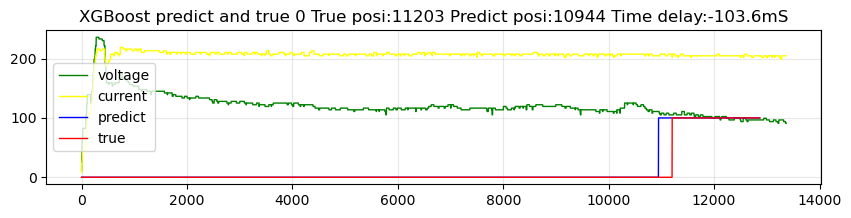

已完成: 100%|██████████████| 93/93 [00:00<00:00, 515.71it/s]


(12330, 8)


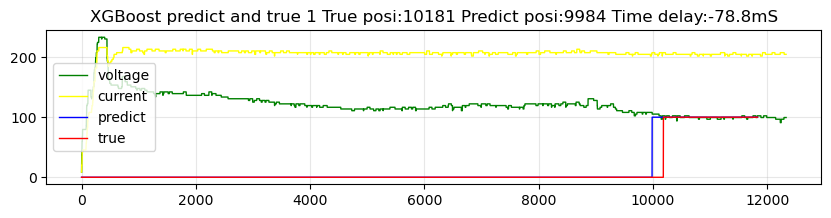

已完成: 100%|██████████████| 86/86 [00:00<00:00, 516.57it/s]


(11397, 8)


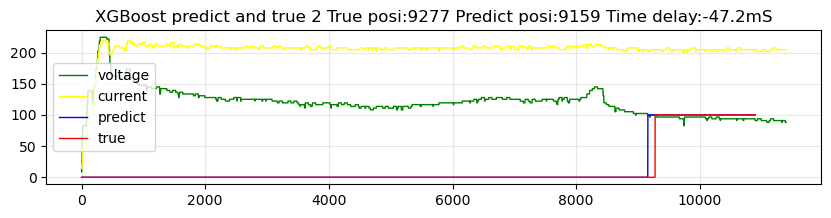

已完成: 100%|████████████| 106/106 [00:00<00:00, 573.65it/s]


(13956, 8)


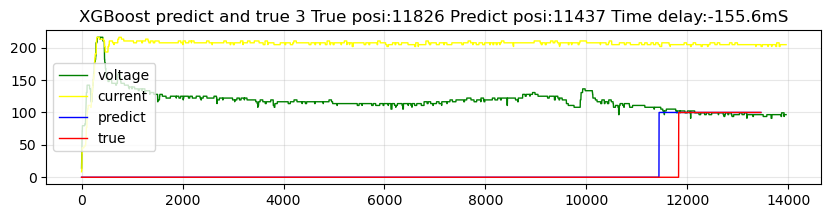

已完成: 100%|██████████████| 70/70 [00:00<00:00, 531.50it/s]


(9423, 8)


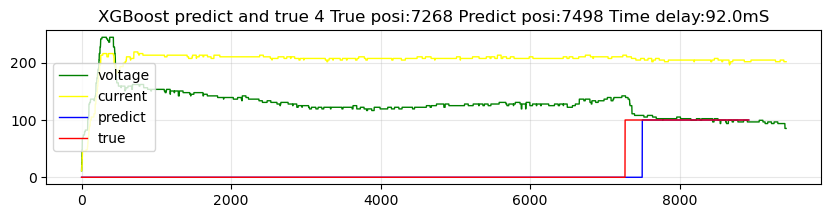

已完成: 100%|██████████████| 92/92 [00:00<00:00, 562.91it/s]


(12170, 8)


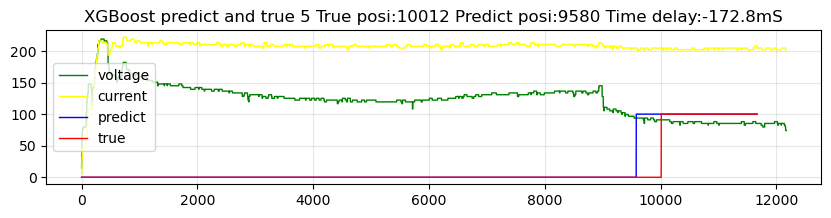

已完成: 100%|████████████| 101/101 [00:00<00:00, 560.25it/s]


(13354, 8)


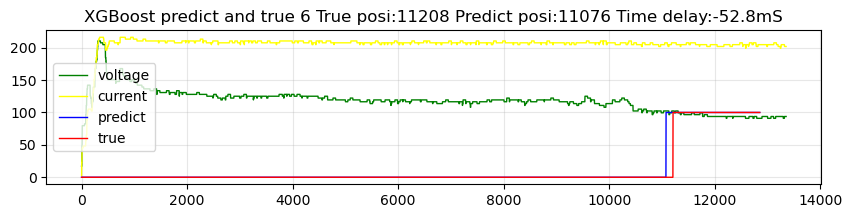

已完成: 100%|████████████| 102/102 [00:00<00:00, 582.67it/s]


(13541, 8)


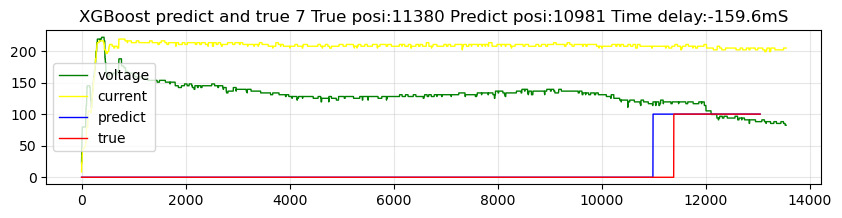

已完成: 100%|██████████████| 76/76 [00:00<00:00, 610.26it/s]


(10185, 8)


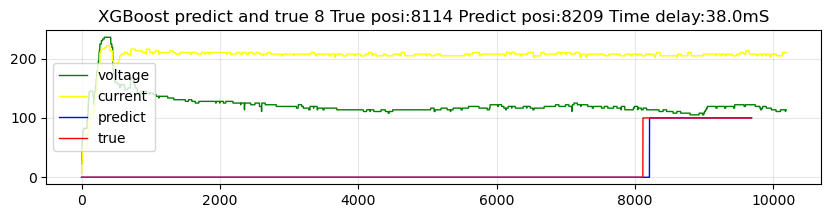

已完成: 100%|██████████████| 91/91 [00:00<00:00, 613.33it/s]


(12066, 8)


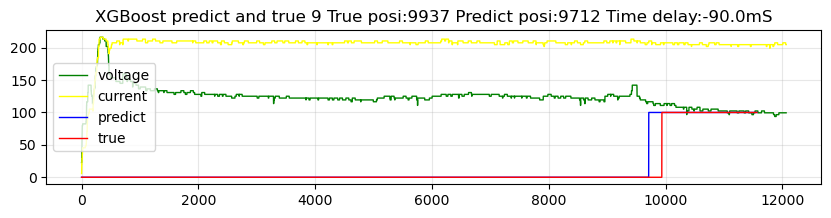

XGBoost模型评估完成
完成时间20251216_033344
结果保存在Test_results_XGBoost


In [4]:
import matplotlib.pyplot as plt
import time
from datetime import datetime

print(f'{model_name}开始模型评估...')
delay_result = []
test_sequences = sequences_data

for i in range(Sample_size):
    test_dataset = MultiSequenceDataset(test_sequences[i], sequence_length, prediction_horizon)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    epoch_start_time = time.time()
    probabilities, predictions, targets = evaluate_model(model, test_loader, device, threshold)
    epoch_time = time.time() - epoch_start_time

    # first_one_true = 0
    # first_one_predict = 0
    first_one_true = np.argmax(targets == 1) #找到第一个1的位置
    if targets[first_one_true] == 1:  # 确保确实找到了1
        targets[first_one_true:] = 100
        
    first_one_predict = np.argmax(predictions == 1) #找到第一个1的位置
    if predictions[first_one_predict] == 1:  # 确保确实找到了1
        predictions[first_one_predict:] = 100

    sequence = test_sequences[i]
    
    # 分离特征和标签
    sequence_features = sequence[:, :-1]
    sequence_labels = sequence[:, -1:]
    
    # 使用对应的scaler
    scaler = scalers[i]
    recovered_features = scaler.inverse_transform(sequence_features)
    
    # 重新组合
    recovered_sequence = np.column_stack((recovered_features, sequence_labels))
    
    voltage = recovered_sequence[:, 0]
    current = recovered_sequence[:, 1]

    print(recovered_sequence.shape)
    
    #基于阻抗变化率的预警
    # test = recovered_sequence[:, 5]
    # test [:7000] = 0
    # old_predict = np.zeros(recovered_sequence.shape[0])
    # first_old_predict = np.argmax(abs(test) > 50)
    # if abs(test[first_old_predict]) > 50:  # 确保确实找到了
    #     old_predict[first_old_predict:] = 100
    
    plt.figure(figsize=(10, 2))
    plt.plot(voltage, label='voltage', color='green', linewidth=1)
    plt.plot(current, label='current', color='yellow', linewidth=1)
    # plt.plot(old_predict, label='old_predict', color='orange', linewidth=1)
    plt.plot(predictions, label='predict', color='blue', linewidth=1)
    plt.plot(targets, label='true', color='red', linewidth=1)
    Delay_time = (first_one_predict - first_one_true)*0.4
    plt.title(f'{model_name} predict and true {i} True posi:{first_one_true} Predict posi:{first_one_predict} Time delay:{Delay_time:.1f}mS')
    plt.legend()  # 显示图例
    plt.grid(True, alpha=0.3)
    save_dir = f'Test_results_{model_name}'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, f'model_evaluation{i}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    delay_result.append({
        'index':i,
        'True':first_one_true,
        #'diff':first_old_predict,
        f'{model_name}':first_one_predict,
        f'{model_name} Delay':Delay_time,
        f'{model_name} perdict_time mS':epoch_time * 1000 / len(test_sequences[i])
    })
    # print(len(test_sequences[i]))

print(f'{model_name}模型评估完成')
df = pd.DataFrame(delay_result)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"完成时间{timestamp}")
print(f'结果保存在{save_dir}')

In [5]:
print(df[f'{model_name} Delay'].to_string(index=False))

-103.6
 -78.8
 -47.2
-155.6
  92.0
-172.8
 -52.8
-159.6
  38.0
 -90.0
